# Выбор локации для скважины

Компании «ГлавРосГосНефть» нужно решить, где бурить новую скважину.

Есть пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Нужно построить модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль и проанализировать возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.  

ЦЕЛЬ: 
- Определить регион, где добыча принесёт наибольшую прибыль

ОПИСАНИЕ ДАННЫХ:
- Данные геологоразведки трёх регионов находятся в файлах: 
`/datasets/geo_data_0.csv`
`/datasets/geo_data_1.csv`
`/datasets/geo_data_2.csv`
- `id` — уникальный идентификатор скважины;
- `f0, f1, f2` — три признака точек (неважно, что они означают, но сами признаки значимы);
- `product` — объём запасов в скважине (тыс. баррелей).

УСЛОВИЯ:

- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые)
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки
- Бюджет на разработку скважин в регионе — 10 млрд рублей
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью

ПЛАН РАБОТ:

1. Загрузим данные, изучим общую информацию, визуализируем и предобработаем данные, проведем исследовательский анализ
2. Обучим и проверим модель для каждого региона
3. Проведем подготовку к расчету прибыли
4. Посчитаем прибыль и риски
5. Сделаем выводы

*ИМПОРТЫ*

In [1]:
!pip install scikit-learn==1.1.3 -q
!pip install phik -q

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.random import RandomState
from scipy import stats as st

In [3]:
from sklearn.model_selection import train_test_split
# преобразование данных
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler
)
from sklearn.impute import SimpleImputer
# модели
from sklearn.linear_model import LinearRegression   
# метрики
from sklearn.metrics import (
    mean_squared_error
    )
# пайплайн
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# автоподбор гиперпараметров
#from sklearn.model_selection import GridSearchCV
import time
import phik

*КОНСТАНТЫ*

In [4]:
RANDOM_STATE = 42
# Доход с каждой единицы продукта, тыс. руб.
PROFIT = 450
# Бюджет на разработку скважин в регионе, тыс. руб.
BUDGET = 10000000
# Количество выбранных лучших точек для разработки в регилне, шт.
N = 200

*ПОЛЬЗОВАТЕЛЬСКИЕ ФУНКЦИИ*

In [5]:
def hist_box_num_feature (df):
    '''
    Возвращает гистограмму и boxplot непрерывных признаков.
            Параметры:
                    df: входящий датасет  
            Возвращаемое значение:
                    plt.show(): вывод гистограммы и ящика с усами
            Для корректной работы тип непрерывных признаков  - float64
    '''
    for feature in df.select_dtypes(include=['float64']).columns.tolist():
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
        df[feature].plot(kind='hist', bins=10, ax=axes[0])
        axes[0].set_title(f'Признак: {feature} \n Гистограмма распределения')
        axes[0].set_ylabel("Количество наблюдений")
        axes[0].set_xlabel(f'{feature}')
        df[feature].plot(kind='box', ax=axes[1])
        axes[1].set_title(f'Признак: {feature} \n Разброс значений')
        plt.ylabel("Значение признака")
        plt.grid(True)
        plt.show()

In [6]:
def barh_feature_name (df, feature):
    '''
    Возвращает столбчатую диаграмму дискретного/категориального признака.
            Параметры:
                    df: входящий датасет
                    feature: признак
            Возвращаемое значение:
                    plt.show(): вывод столбчатой диаграммы
    '''
    ax = df[feature].value_counts(ascending=True).plot.barh(figsize=(8,3))
    plt.xlabel("Количество наблюдений")
    plt.grid(True)
    plt.title(f'Распределение признака: {feature}')
    return plt.show()

In [7]:
def drop_duplicates_id (df):
    '''
    Возвращает датасет без всех вхождений дублей id
            Параметры:
                    df: входящий датасет
            Возвращаемое значение:
                    df: датасет без дублей
    '''
    id_duplicates = df[df['id'].duplicated()]
    for id_value in id_duplicates['id'].unique():
        df = df.drop(df[df['id'] == id_value].index)
    return df.reset_index(drop=True)

In [8]:
def phik_corr (df):
    '''
    Возвращает матрицу корреляции Фи
            Параметры:
                    df: входящий датасет
            Возвращаемое значение:
                    матрица корреляции
            Для корректной работы тип непрерывных признаков  - float64
    '''
    plt.figure(figsize = (6,5))
    ax = sns.heatmap(df.drop('id', axis=1).phik_matrix(
        interval_cols=df.select_dtypes(include=['float64']).columns.tolist()), 
        annot=True, fmt='.2f', cmap= 'coolwarm')

In [9]:
def product_pred (df):
    '''
    Возвращает валидационную выборку с колонками предсказаний 
    и правильных ответов, rmse модели
                    df: входящий датасет
            Возвращаемое значение: 
                    X_valid: выборка с добавленными колонками
                    rmse: метрика rmse
    '''
    # Разобьем на выборки (по умолчанию 3:1)
    X = df.drop(['id','product'] , axis=1)
    y = df['product']
    X_train, X_valid, y_train, y_valid = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE
    )
    # Все данные разномасштабные, поэтому скейлерить будем все фичи
    num_columns = X.select_dtypes(include=['float64']).columns.tolist()
    
    # Для подготовки данных используем пайплайн ColumnTransformer
    # В качестве скейлера возьмем StandardScaler 
    # remainder='passthrough' оставим (вдруг часть пирзаков передумаем масштабировать)
    data_preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
    )

    # Соберем финальный пайплайн с линейной регрессией
    pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
    )
    # Обучим пайплайн, получим предсказания для валидационной выборки
    # Добавим столбцы с предсказаниями и правильными ответами
    pipe_final.fit(X_train, y_train)
    y_pred = pipe_final.predict(X_valid)
    X_valid['product_pred'] = y_pred
    X_valid['product_true'] = y_valid
    
    # Посчитаем rmse
    rmse = mean_squared_error(y_valid, y_pred, squared=False)
    return X_valid, rmse

In [10]:
def product_profit (df, n):
    '''
    Возвращает объем сырья и прибыль по выбранным n скважинам
                df: входящий датасет
                n: количество выбранных скважин
            Возвращаемое значение: 
                product_profit: прибыль, тыс. руб 
    '''
    product_profit = df.sort_values(
        by='product_pred', ascending=False
        ).reset_index(drop=True).loc[:n-1, 'product_true'].sum()*profit
    return product_profit   

## Загрузка и подготовка данных

### Считаем файлы с данными и изучим общую информацию

In [11]:
try:
    geo_data_0 = pd.read_csv('geo_data_0.csv')
    geo_data_1 = pd.read_csv('geo_data_1.csv')
    geo_data_2 = pd.read_csv('geo_data_2.csv')
except:
    geo_data_0 = pd.read_csv(
        'https://code.s3.yandex.net/datasets/geo_data_0.csv')
    geo_data_1 = pd.read_csv(
        'https://code.s3.yandex.net/datasets/geo_data_1.csv')
    geo_data_2 = pd.read_csv(
        'https://code.s3.yandex.net/datasets/geo_data_2.csv')

In [12]:
geo_data_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [13]:
geo_data_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [14]:
geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [15]:
geo_data_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [16]:
geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [17]:
geo_data_2.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


*ВЫВОД: Все признаки числовые непрерывные, без очевидных пропусков*

### Предобработка данных

*Названия столбцов и типы данных оставим без изменений, проверим пропуски и дубликаты*

In [18]:
dfs = [geo_data_0, geo_data_1, geo_data_2]

In [19]:
for df in dfs:
    print(f'Пропуски: \n{df.isna().sum()}')
    print(f'Дубликаты: {df.duplicated().sum()}')

Пропуски: 
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Дубликаты: 0
Пропуски: 
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Дубликаты: 0
Пропуски: 
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Дубликаты: 0


*ВЫВОД: Пропусков и полных дубликатов нет. Посмотрим уникальные id*

In [20]:
for df in dfs:
    print(df['id'].nunique())

99990
99996
99996


*ВЫВОД: В id есть дубликаты, посмотрим на них на первом датасете*

In [21]:
geo_data_0[geo_data_0['id'].duplicated()]

,id,f0,f1,f2,product
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
41724,bxg6G,-0.823752,0.546319,3.630479,93.007798
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
66136,74z30,1.084962,-0.312358,6.990771,127.643327
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
75715,Tdehs,0.112079,0.430296,3.218993,60.964018
90815,fiKDv,0.049883,0.841313,6.394613,137.346586
92341,TtcGQ,0.110711,1.022689,0.911381,101.318008
97785,bsk9y,0.378429,0.005837,0.160827,160.637302


In [22]:
geo_data_0[geo_data_0['id'] == 'HZww2']

,id,f0,f1,f2,product
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695


*ВЫВОД: id это уникальный идентефикатор, поэтому если в id есть дубликаты, то это очевидно ошибка. Дубликаты необходимо удалить. Однако, какое вхождение удалять? Первое второе или оба? На данном этапе не понятно. Примем решение после исследовательского анализа*

*Строго говоря, id не является признаком для обучения модели, однако, дальнейшая работа с данными при дублях id может привести к дополнительным ошибкам*

### Исследовательский анализ

*Все признаки коллиичественные непрерывные, для их визуализации подойдут гистограммы и ящик с усами*

#### Посмотрим описательные статистики, гистограммы и "ящики с усами"

In [23]:
for df in dfs:
    print(df.describe())

                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985       1.000021      26.953261
50%       

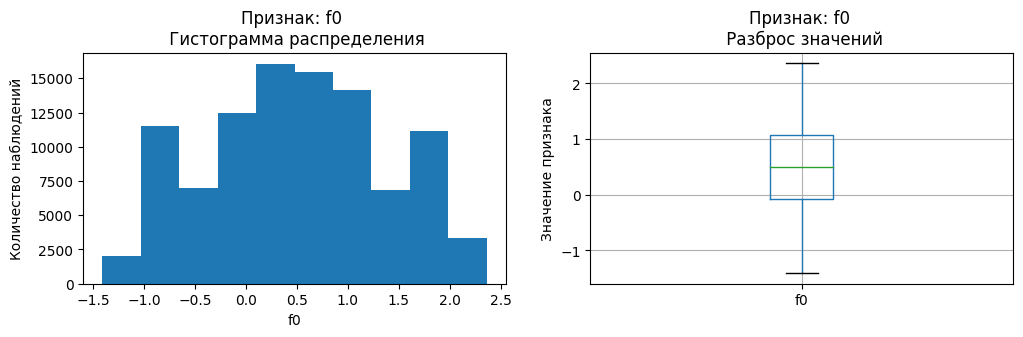

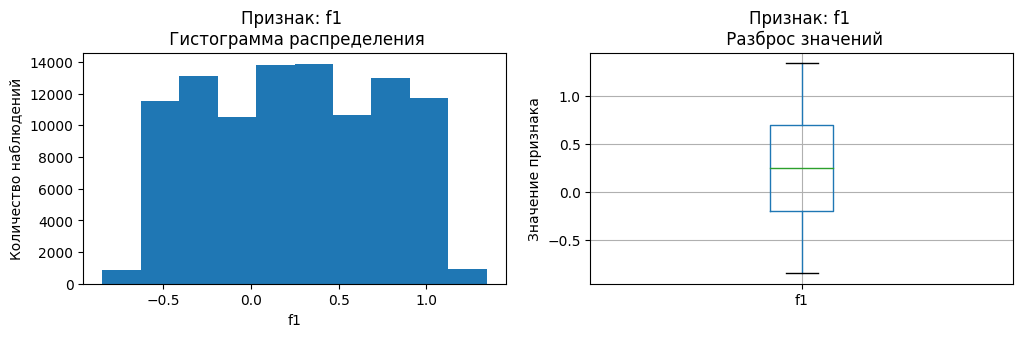

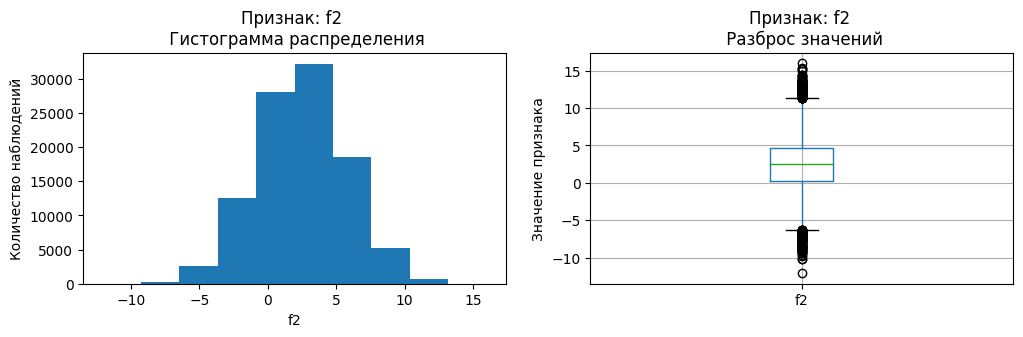

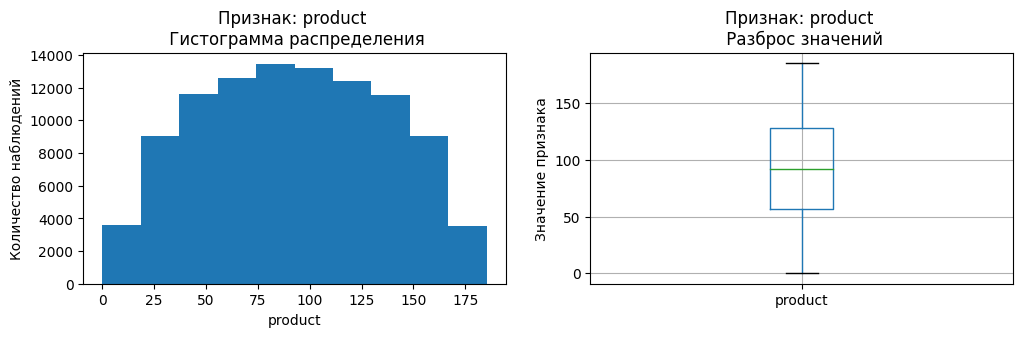

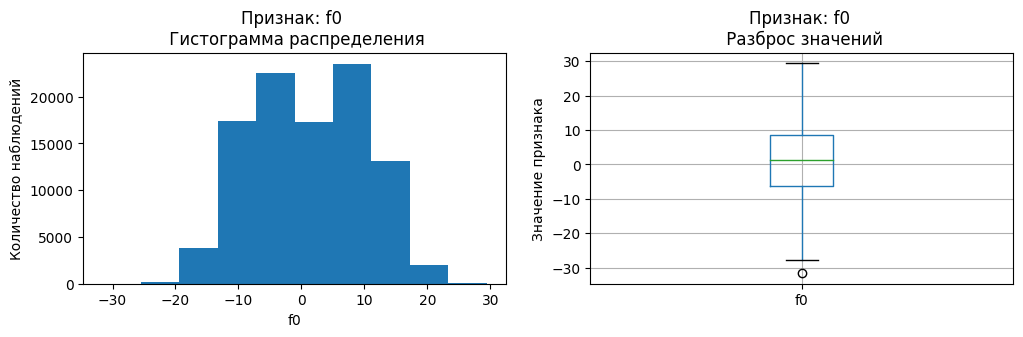

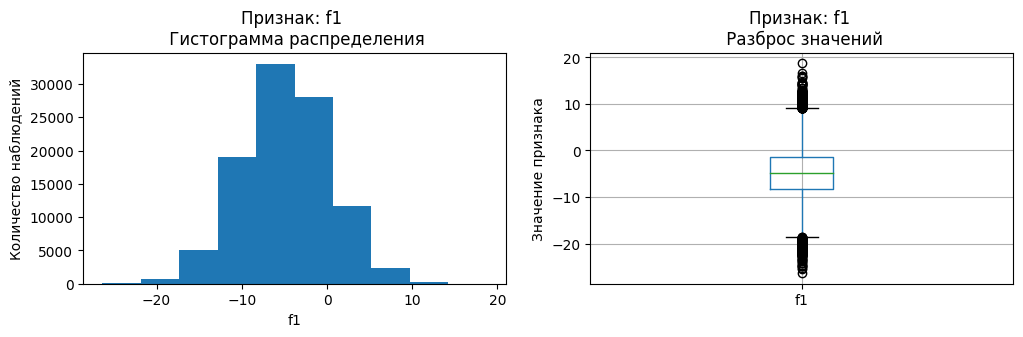

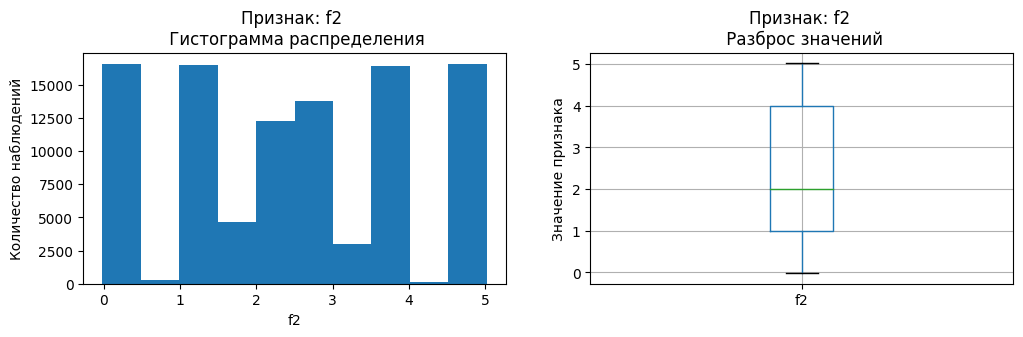

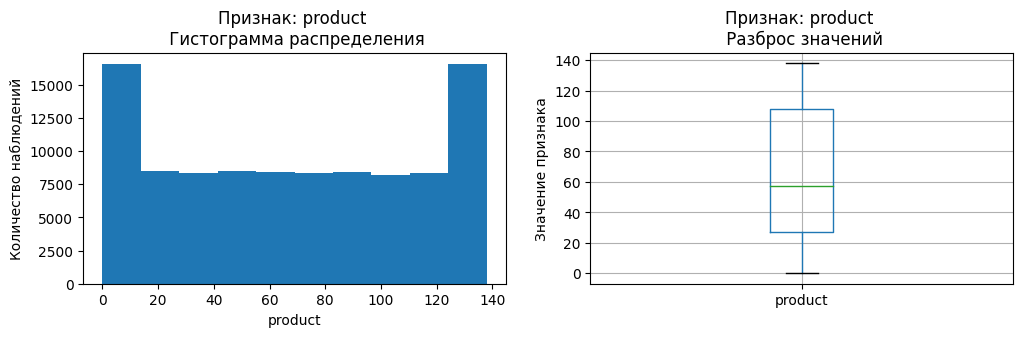

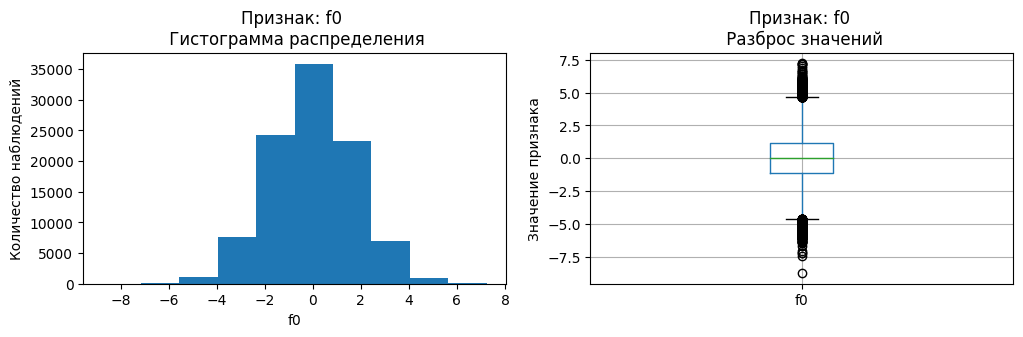

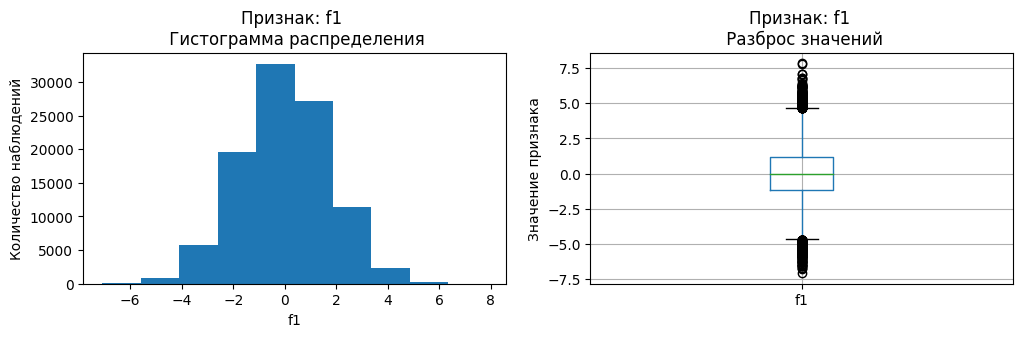

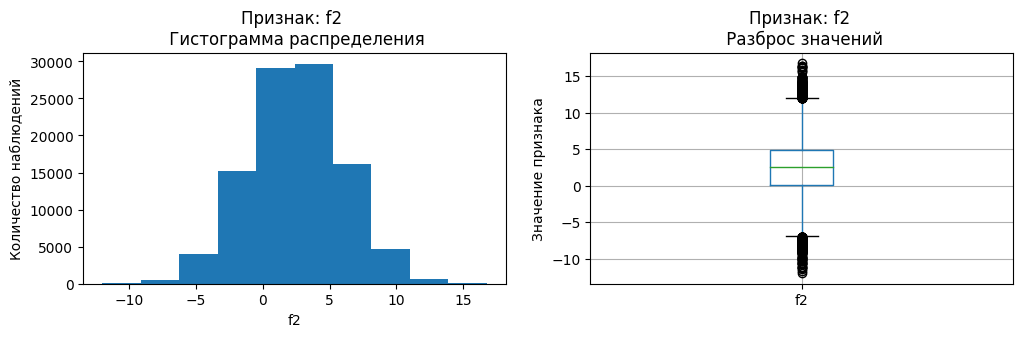

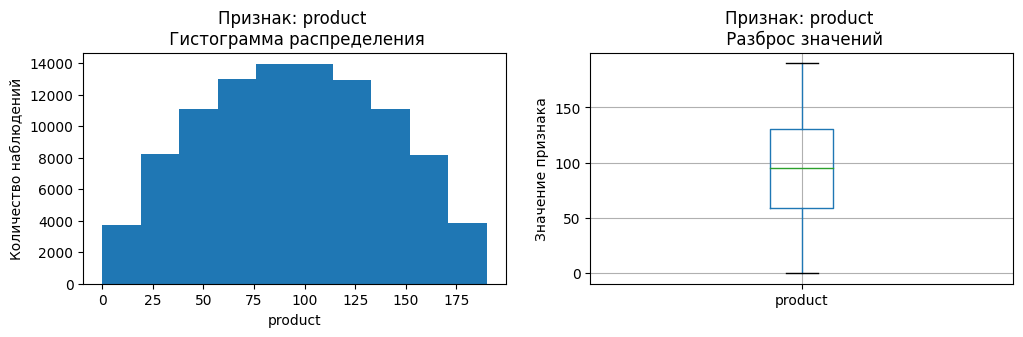

In [24]:
for df in dfs:
    hist_box_num_feature(df.drop('id', axis=1))

*Проверим целевой на уникальность*

In [25]:
for df in dfs:
    print(df['product'].nunique())

100000
12
100000


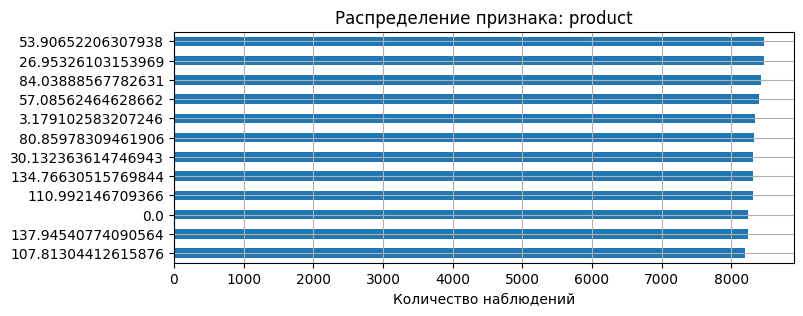

In [26]:
barh_feature_name(geo_data_1, 'product')

*ВЫВОД: 
- по стандартным отклонениям признаки - изменяемые
- атипичных аномалий не выявлено
- есть некоторое количество выбросов, но атипичными их назвать нельзя
- некоторые распределения напоминают нормальные, а некоторые абсолютно нет
- целевой признак одного из регионов имеет всего 12 уникальных знвчений из 100 000 наблюдений, это необычно, будем считать его разряженным непрерывным
- причину появления дубликатов id установить не удалось, удалим все вхождения, возможно, лучше потерять часть данных, чем исказить их достоверность
- для признаков необходимо использовать скейлер*

In [27]:
geo_0 = drop_duplicates_id(geo_data_0)
geo_1 = drop_duplicates_id(geo_data_1)
geo_2 = drop_duplicates_id(geo_data_2)

In [28]:
geo_0.tail()

,id,f0,f1,f2,product
99975,DLsed,0.971957,0.370953,6.075346,110.744026
99976,QKivN,1.392429,-0.382606,1.273912,122.346843
99977,3rnvd,1.029585,0.018787,-1.348308,64.375443
99978,7kl59,0.998163,-0.528582,1.583869,74.040764
99979,1CWhH,1.764754,-0.266417,5.722849,149.633246


#### Для корреляционного анализа построим матрицы корреляции

*Так как признаки не распределены нормально, нам лучше подойдет коэффициент корреляции Фи. Построим матрицы корреляций. Передадим параметру interval_cols список непрерывных признаков*

In [29]:
dfs_no_duplicates = [geo_0, geo_1, geo_2]

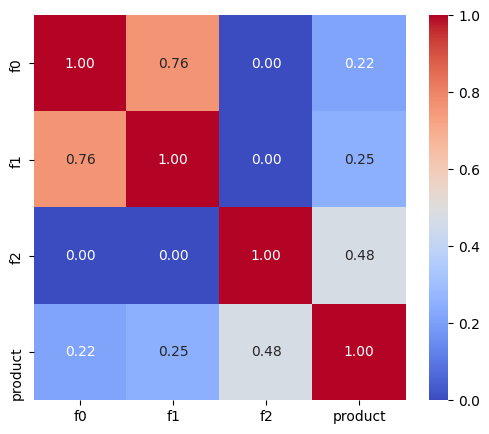

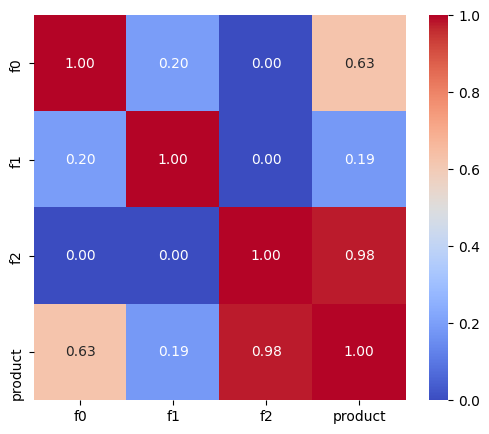

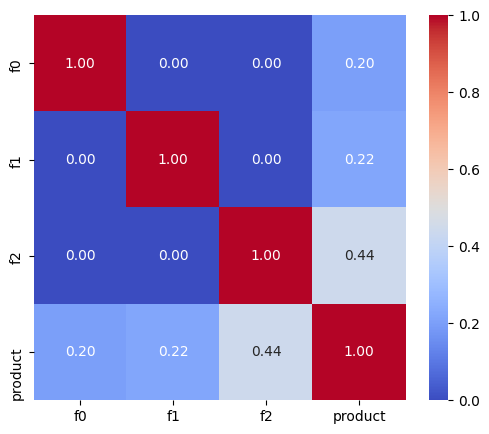

In [30]:
for df in dfs_no_duplicates:
    phik_corr(df)

*ВЫВОД: 
- Регион 0: корреляция таргета и входных фичей не очень высокая, `f0` и `f1` коррелируют между собой сильнее, чем с таргетом, но не достаточно, чтобы назвать это мультиколлинеарностью
- Регион 1: интересная картина у `f2` с таргетом корреляция 0,98, смахивает на утечку...
- Регион 2: все в холодной зоне. Все со всем коррелирует не очень-то*

## Обучение и проверка модели

### Разобьем данные на обучающую и валидационную выборки в соотношении 75:25 

### Обучим модель и сделаем предсказания на валидационной выборке

### Сохраним предсказания и правильные ответы на валидационной выборке

*Для п 2.1- 2.3 воспользуемся пользовательской функцией `product_pred`*

In [31]:
geo_valid_0, rmse_0 = product_pred(geo_0)
geo_valid_0.head()

,f0,f1,f2,product_pred,product_true
68281,0.096378,-0.200314,9.052483,140.415284,111.261742
40554,-0.268458,0.921819,3.194225,84.683193,3.240789
54244,1.604150,-0.317233,7.668558,138.812581,156.430554
70623,1.577117,-0.495010,4.082067,117.496790,137.684050
44352,0.313237,-0.206565,-0.910742,75.558549,126.213790


In [32]:
geo_valid_1, rmse_1 = product_pred(geo_1)
geo_valid_1.head()

,f0,f1,f2,product_pred,product_true
33965,0.518707,-5.983575,0.001335,1.745802,0.000000
22853,-9.630271,-11.453777,2.996499,84.064523,84.038886
19448,7.486573,-11.046265,4.006074,108.784312,107.813044
9732,10.448037,0.297406,1.011815,27.400959,26.953261
7129,12.857577,-7.534200,0.010287,0.233071,0.000000


In [33]:
geo_valid_2, rmse_2 = product_pred(geo_2)
geo_valid_2.head()

,f0,f1,f2,product_pred,product_true
33965,2.320681,-1.526151,3.003304,97.751163,58.166745
22853,-0.714721,1.985878,2.593923,95.522584,179.573608
19448,-2.924051,2.719300,5.318565,111.332198,160.193413
9732,0.500312,-1.925757,-3.053501,62.984886,34.079047
7129,-2.202068,2.999640,10.552605,141.426676,138.077543


### Cредний запас предсказанного сырья и RMSE модели

In [34]:
product_pred_mean_0 = geo_valid_0['product_pred'].mean()
print(f'Средний запас предсказанного сырья 1 скважены регион 0: {product_pred_mean_0}')
print(f'RMSE модели регион 0: {rmse_0}')

Средний запас предсказанного сырья 1 скважены регион 0: 92.2865385223536
RMSE модели регион 0: 37.76114714593895


In [35]:
product_pred_mean_1 = geo_valid_1['product_pred'].mean()
print(f'Средний запас предсказанного сырья 1 скважены регион 1: {product_pred_mean_1}')
print(f'RMSE модели регион 1: {rmse_1}')

Средний запас предсказанного сырья 1 скважены регион 1: 69.16894101447984
RMSE модели регион 1: 0.892863589877732


In [36]:
product_pred_mean_2 = geo_valid_2['product_pred'].mean()
print(f'Средний запас предсказанного сырья 1 скважены регион 2: {product_pred_mean_2}')
print(f'RMSE модели регион 2: {rmse_2}')

Средний запас предсказанного сырья 1 скважены регион 2: 94.82069136328788
RMSE модели регион 2: 40.13115560413051


### Вывод

*В регионах 0 и 2 картины схожие, близкие значения средних запасов сырья, близкие друг другу rmse. В регионе 1 значение среднего запаса сырья поменьше, а rmse 0,89!!!! Это удивительный результат, хотя предсказуемый с учетом корреляции, которую мы наблюдали. Проверить признаки на утечку мы не можем, не хватает данных. Примем результат как есть*

## Подготовка к расчёту прибыли

### Ключевые значения для расчетов прибыли

In [37]:
profit = PROFIT
budget = BUDGET
n = N

### Рассчет достаточного объёма сырья для безубыточной разработки новой скважины

In [38]:
f' Минимальный объём сырья для безубыточной разработки новой скважины: {(1/n)*budget/profit} тыс. баррелей'

' Минимальный объём сырья для безубыточной разработки новой скважины: 111.11111111111111 тыс. баррелей'

### Вывод

*Минимальный объем сырья для безубыточной разработки новой скважины выше, чем средний запас предсказанного сырья для всех 3-х регионов. Поэтому в n выбранных для разработки скважин должны войти лучшие по предсказанному объему сырья*

## Для расчёта прибыли по выбранным скважинам и предсказаниям модели воспользуемся пользовательской функцией `product_profit`

### Внутри функции выберем скважины с максимальными значениями предсказаний

### Внутри функции просуммируем целевое значение объёма сырья, соответствующее этим предсказаниям

*Отбор лучших скважин делаем по предсказаниям, а подсчет объема запасов сырья для этих выбранных лучших скважин считаем по истиным значениям таргета*

### Рассчитаем прибыль для полученного объёма сырья

*В данном случае берем всю валидационную выборку*

In [39]:
print('Регион 0')
print(f'Прибыль для объёма сырья лучших {n} скважин: {0.000001*product_profit(geo_valid_0, n)} млрд.руб.')

Регион 0
Прибыль для объёма сырья лучших 200 скважин: 13.301821343646251 млрд.руб.


In [40]:
print('Регион 1')
print(f'Прибыль для объёма сырья лучших {n} скважин: {0.000001*product_profit(geo_valid_1, n)} млрд.руб.')

Регион 1
Прибыль для объёма сырья лучших 200 скважин: 12.415086696681511 млрд.руб.


In [41]:
print('Регион 2')
print(f'Прибыль для объёма сырья лучших {n} скважин: {0.000001*product_profit(geo_valid_2, n)} млрд.руб.')

Регион 2
Прибыль для объёма сырья лучших 200 скважин: 12.103914701299196 млрд.руб.


## Расчёт прибыли и рисков 

### Применим технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли

*Воспользуемя .sample() для получения выборок и RandomState, чтобы выборки были каждый раз разные*

In [42]:
state = RandomState(12345)

### Найдем среднюю прибыль, 95%-й доверительный интервал и риск убытков

In [43]:
dfs_valid = [geo_valid_0, geo_valid_1, geo_valid_2]

In [44]:
region = -1
for df in dfs_valid:
    region += 1
    values = []
    count = 0
    for i in range(1000):
        df_subsample = df.sample(500, replace=True, random_state=state)
        values.append(product_profit(df_subsample, n))
        if product_profit(df_subsample, n)<10000000:
            count += 1
    values = pd.Series(values)

    print(f'Регион {region}')
    print(f'Средняя прибыль на основании 1000 выборок по 500 скважин')
    print(f'c выбором {n} лучших: {0.000001*values.mean()} млрд. руб.')
    print(f'С вероятностью 95% средняя прибыль от {n} скважин региона') 
    print(f'будет более {0.000001*values.quantile(0.05)} млрд. руб.')
    print(f'Вероятность убытков составляет {100*count/1000} %')

Регион 0
Средняя прибыль на основании 1000 выборок по 500 скважин
c выбором 200 лучших: 10.396713209984348 млрд. руб.
С вероятностью 95% средняя прибыль от 200 скважин региона
будет более 9.964717368910254 млрд. руб.
Вероятность убытков составляет 7.2 %
Регион 1
Средняя прибыль на основании 1000 выборок по 500 скважин
c выбором 200 лучших: 10.483529594859853 млрд. руб.
С вероятностью 95% средняя прибыль от 200 скважин региона
будет более 10.154850499737513 млрд. руб.
Вероятность убытков составляет 0.9 %
Регион 2
Средняя прибыль на основании 1000 выборок по 500 скважин
c выбором 200 лучших: 10.356796976765953 млрд. руб.
С вероятностью 95% средняя прибыль от 200 скважин региона
будет более 9.926055829616235 млрд. руб.
Вероятность убытков составляет 10.0 %


### Вывод

*По условиям к разработке могут быть рекомендованы лишь те регионы, в которых вероятность убытков меньше 2.5%. Под это условие подходит только регион 1 (вероятность убытков 0.9%). Нюансы:
- У данных для этого региона есть некоторые странности - у таргета (числовой непрерывный) всего 12 уникальных значений при при 100 000 наблюдений
- Корреляция таргета с одним из признаков 0,98, что крайне необычно для реальных данных
- Модель, обученная на данных для этого региона практически не ошибается (RMSE = 0.89 при среднем предсказании 69)
- Если в рамках данного проекта принять допущение, что здесь нет ошибки и утечки целевого признака, то по показателям средней прибыли, доверительного интервала и риска убытков, полученным с помощью техники Bootstrap с 1000 выборок, регион 1 занимает почетное первое место*